# Bayesian Optimization using Gaussian Process Regression

This notebook demonstrates Bayesian Optimization, an efficient technique for optimizing expensive black-box functions. It uses Gaussian Process (GP) regression to model the function and the Lower Confidence Bound (LCB) strategy to decide where to sample next.

Bayesian Optimization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# the true function to optimize (we pretend we don't know this)
def true_function(X):
    return np.sin(X) + 2 * np.cos(X)

print("True function: y = sin(x) + 2*cos(x)")
print("Goal: Find x that minimizes y using as few function evaluations as possible")

True function: y = sin(x) + 2*cos(x)
Goal: Find x that minimizes y using as few function evaluations as possible




I then added the functionality to the rbf_kernal, by adding the variables to determine the reshapes for each value, which computes the radial basis function (the similarity measure between every pair of points) 



In [ ]:

def rbf_kernel(X1, X2):
    """
    Compute RBF (Gaussian) kernel between X1 and X2
    k(x_i, x_j) = exp(-||x_i - x_j||^2)
    """
    X1_mat = X1.ravel()[:, np.newaxis]  
    X2_mat = X2.ravel()[np.newaxis, :]  #
    

    sq_dist = (X1_mat - X2_mat) ** 2
    

    K = np.exp(-sq_dist)
    
    return K

X1 = np.array([[1], [2], [3]])
X2 = np.array([[1], [2], [3]])

K = rbf_kernel(X1, X2)

print("8.1)-1: RBF Kernel Test")
print(f"X1 shape: {X1.shape}")
print(f"X2 shape: {X2.shape}")
print(f"Kernel K shape: {K.shape}")
print()
print("RBF Kernel Matrix (distance-based similarity):")
print(np.round(K, 4))
print()
print("Note: Diagonal is 1.0 (perfect similarity), off-diagonal decreases with distance")

8.1)-1: RBF Kernel Test
X1 shape: (3, 1)
X2 shape: (3, 1)
Kernel K shape: (3, 3)

RBF Kernel Matrix (distance-based similarity):
[[1.     0.3679 0.0183]
 [0.3679 1.     0.3679]
 [0.0183 0.3679 1.    ]]

Note: Diagonal is 1.0 (perfect similarity), off-diagonal decreases with distance




Then, I perform the GP regression but adding the rbf_kernal functionalities, which gives predictions and uncertainty at test points which is utlized via the back mu and covariance. The uncertainty will tell us which regions are underexplored



In [ ]:

def gaussian_regression(X_train, y_train, X_test):

    K_train = rbf_kernel(X_train, X_train)

    K_train_inv = np.linalg.inv(K_train)

    k_test_train = rbf_kernel(X_test, X_train)  

    k_test_test = rbf_kernel(X_test, X_test)   

    mu_star = k_test_train @ K_train_inv @ y_train
    
    sigma_star = k_test_test - k_test_train @ K_train_inv @ k_test_train.T
    
    return mu_star, sigma_star

print("8.1)-2: Gaussian Process Regression initialized")

8.1)-2: Gaussian Process Regression initialized



Then, i called the gaussian regression function for x=2.2, and extracted the standard deviation of the diagnonal of the covariance matrix.



In [ ]:

print("="*70)
print("8.1)-3: Single Point Prediction")
print("="*70)


X_train = np.array([[1], [2], [4], [6], [8], [9]])
y_train = true_function(X_train).ravel()

print(f"Training points: {X_train.ravel()}")
print(f"Training values: {np.round(y_train, 4)}")
print()

# predict at x = 2.2
X_test_single = np.array([[2.2]])
mu_single, sigma_single = gaussian_regression(X_train, y_train, X_test_single)
sd_single = np.sqrt(np.diag(sigma_single))

print(f"Test point: x = {X_test_single[0, 0]}")
print(f"Predicted mean (μ*):           {mu_single[0]:.4f}")
print(f"Predicted std dev (σ):         {sd_single[0]:.4f}")
print(f"True value (ground truth):     {true_function(X_test_single)[0, 0]:.4f}")
print()
print("Interpretation:")
print(f"  GP predicts ~{mu_single[0]:.2f} ± {sd_single[0]:.2f} (95% CI: [{mu_single[0] - 1.96*sd_single[0]:.2f}, {mu_single[0] + 1.96*sd_single[0]:.2f}])")

8.1)-3: Single Point Prediction
Training points: [1 2 4 6 8 9]
Training values: [ 1.9221  0.077  -2.0641  1.6409  0.6984 -1.4101]

Test point: x = 2.2
Predicted mean (μ*):           -0.2243
Predicted std dev (σ):         0.2465
True value (ground truth):     -0.3685

Interpretation:
  GP predicts ~-0.22 ± 0.25 (95% CI: [-0.71, 0.26])


Then, we expand the preductions from a single point to 10 evenly spaced test points accross, giving us the full picture of what GP predicts across the seach space.

In [ ]:
print("\n" + "="*70)
print("Question 2: Extended Test Set (10 points)")
print("="*70)


X_test = np.linspace(0, 10, 10).reshape(-1, 1)
mean, sigma = gaussian_regression(X_train, y_train, X_test)
sd = np.sqrt(np.diag(sigma))

print(f"\nTest points: {np.round(X_test.ravel(), 2)}")
print()
print("Predicted means (μ*):")
print(np.round(mean, 4))
print()
print("Predicted std devs (σ):")
print(np.round(sd, 4))
print()
print("Observations:")
print("  - Points near training data have low uncertainty")
print("  - Points far from training data have high uncertainty")
print("  - Uncertainty increases at boundaries (x=0, x=10)")


Question 2: Extended Test Set (10 points)

Test points: [ 0.    1.11  2.22  3.33  4.44  5.56  6.67  7.78  8.89 10.  ]

Predicted means (μ*):
[ 0.7873  1.8363 -0.2519 -1.44   -1.5635  1.1759  1.2826  0.9467 -1.2685
 -0.6795]

Predicted std devs (σ):
[0.9213 0.1222 0.2742 0.7488 0.5663 0.5663 0.7488 0.2742 0.1222 0.9213]

Observations:
  - Points near training data have low uncertainty
  - Points far from training data have high uncertainty
  - Uncertainty increases at boundaries (x=0, x=10)


Then, I added the kappa, lcb, next_idx and next_x values. the low mu values are predicted to be good. the high uncertainty means there is unexplored regions worth checking, and the LCB rewards both by subtracting the explortation bonus



In [ ]:
print("\n" + "="*70)
print("Question 3: Lower Confidence Bound (LCB) Acquisition")
print("="*70)


kappa = 1.96  
lcb = mean - kappa * sd

print(f"\nUsing κ = {kappa} (X% confidence interval)")
print()
print("LCB values for each test point:")
print("-" * 70)
for i, (x, mu, s, lcb_val) in enumerate(zip(X_test.ravel(), mean, sd, lcb)):
    print(f"x={x:6.2f}: μ={mu:7.4f}, σ={s:7.4f}, LCB = μ - 1.96*σ = {lcb_val:7.4f}")

next_idx = np.argmin(lcb)
next_x = X_test[next_idx]
next_lcb = lcb[next_idx]

print()
print("="*70)
print(f"NEXT POINT TO EVALUATE: x = {next_x[0]:.2f}")
print(f"  LCB value: {next_lcb:.4f}")
print(f"  This is the most promising point for minimization")
print("="*70)


Question 3: Lower Confidence Bound (LCB) Acquisition

Using κ = 1.96 (95% confidence interval)

LCB values for each test point:
----------------------------------------------------------------------
x=  0.00: μ= 0.7873, σ= 0.9213, LCB = μ - 1.96*σ = -1.0185
x=  1.11: μ= 1.8363, σ= 0.1222, LCB = μ - 1.96*σ =  1.5969
x=  2.22: μ=-0.2519, σ= 0.2742, LCB = μ - 1.96*σ = -0.7894
x=  3.33: μ=-1.4400, σ= 0.7488, LCB = μ - 1.96*σ = -2.9076
x=  4.44: μ=-1.5635, σ= 0.5663, LCB = μ - 1.96*σ = -2.6735
x=  5.56: μ= 1.1759, σ= 0.5663, LCB = μ - 1.96*σ =  0.0660
x=  6.67: μ= 1.2826, σ= 0.7488, LCB = μ - 1.96*σ = -0.1850
x=  7.78: μ= 0.9467, σ= 0.2742, LCB = μ - 1.96*σ =  0.4091
x=  8.89: μ=-1.2685, σ= 0.1222, LCB = μ - 1.96*σ = -1.5080
x= 10.00: μ=-0.6795, σ= 0.9213, LCB = μ - 1.96*σ = -2.4852

NEXT POINT TO EVALUATE: x = 3.33
  LCB value: -2.9076
  This is the most promising point for minimization




Finally, I edited the visualizion slightly and I also added a label so we can see our next evaluation point




Question 4: Gaussian Process Regression Visualization


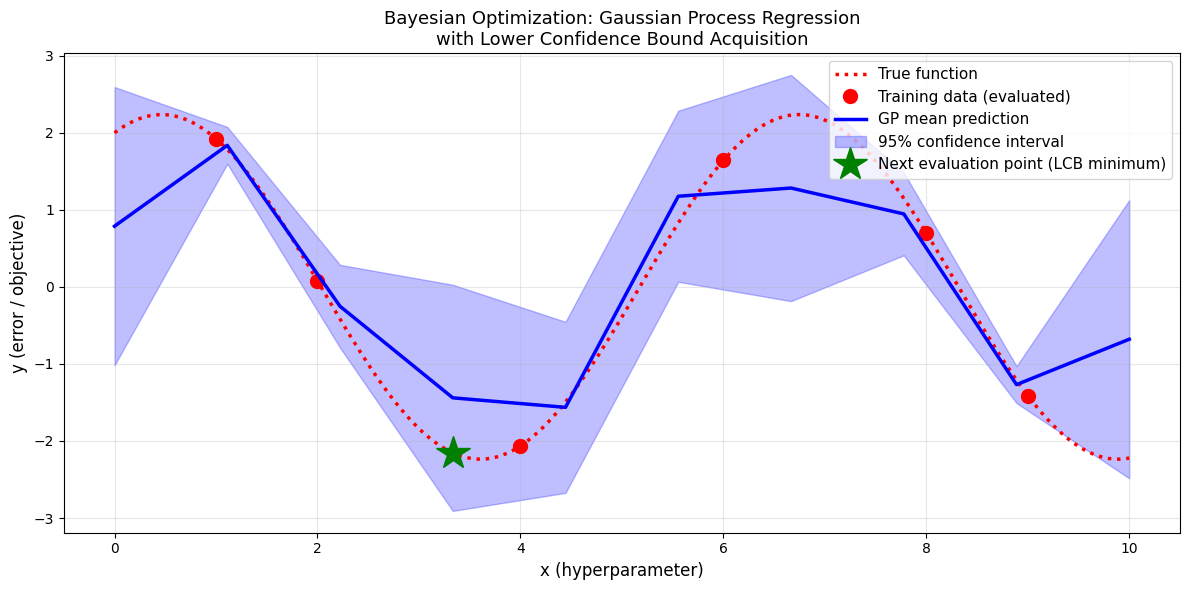

✓ Visualization complete


In [ ]:
print("\n" + "="*70)
print("Question 4: Gaussian Process Regression Visualization")
print("="*70)

plt.figure(figsize=(12, 6))
X_dense = np.linspace(0, 10, 200).reshape(-1, 1)
y_true = true_function(X_dense)
plt.plot(X_dense, y_true, 'r:', linewidth=2.5, label='True function')
plt.plot(X_train, y_train, 'ro', markersize=10, label='Training data (evaluated)')
plt.plot(X_test, mean, 'b-', linewidth=2.5, label='GP mean prediction')
plt.fill_between(X_test.ravel(), 
                 mean - 1.96*sd, 
                 mean + 1.96*sd, 
                 alpha=0.25, color='blue', label='95% confidence interval')
plt.plot(next_x, true_function(next_x), 'g*', markersize=25, label='Next evaluation point (LCB minimum)')

plt.xlabel('x (hyperparameter)', fontsize=12)
plt.ylabel('y (error / objective)', fontsize=12)
plt.title('Bayesian Optimization: Gaussian Process Regression\nwith Lower Confidence Bound Acquisition', fontsize=13)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete")